In [1]:
import torch
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt


In [2]:
class datasets():
    def __init__(self, transforms, df):
        self.t = transforms
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        img = row["image_add"]
        img = self.t(Image.open(img).convert("RGB"))
        lab = row["Class"]
        lab = torch.tensor(lab, dtype=torch.int64)
        return img, lab


In [3]:
import os


In [4]:
os.getcwd()


'C:\\Dash_Strikes\\REAL_VS_AI'

In [5]:
os.listdir()


['.ipynb_checkpoints',
 'DATA',
 'Dataloader_&_Models.ipynb',
 'Dataloader_&_Models_fixed_draft.ipynb',
 'dataset_maker_and_transformer.ipynb',
 'Data_getting.ipynb',
 'Test_Data.csv',
 'Train_Data.csv',
 'Transformed_Data']

In [6]:
train_dataset_32 = torch.load(os.path.join("Transformed_Data/train_dataset_32.pt"), weights_only=False)
train_dataset_256 = torch.load("Transformed_Data/train_dataset_256.pt", weights_only=False)


In [7]:
img, lab = next(iter(train_dataset_32))
img.shape, lab


(torch.Size([3, 32, 32]), tensor(0))

In [8]:
img1, lab1 = next(iter(train_dataset_256))
img1.shape, lab1


(torch.Size([3, 256, 256]), tensor(0))

In [9]:
np.array(img1).shape


C:\Users\divyadarshee dash\AppData\Local\Temp\ipykernel_22668\697792856.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.array(img1).shape


(3, 256, 256)

In [10]:
np.array(img1)[0][1]


C:\Users\divyadarshee dash\AppData\Local\Temp\ipykernel_22668\1967721147.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.array(img1)[0][1]


array([-0.12785512, -0.12785512, -0.11118888, -0.11118888, -0.11118888,
       -0.09452263, -0.09452263, -0.07785638, -0.06119013, -0.04452388,
       -0.04452388, -0.02785764, -0.02785764, -0.02785764, -0.02785764,
       -0.02785764, -0.02785764, -0.04452388, -0.04452388, -0.06119013,
       -0.06119013, -0.07785638, -0.09452263, -0.11118888, -0.11118888,
       -0.12785512, -0.14452137, -0.16118762, -0.16118762, -0.17785387,
       -0.17785387, -0.17785387, -0.19452012, -0.19452012, -0.19452012,
       -0.19452012, -0.19452012, -0.19452012, -0.17785387, -0.17785387,
       -0.16118762, -0.16118762, -0.14452137, -0.14452137, -0.14452137,
       -0.14452137, -0.14452137, -0.14452137, -0.16118762, -0.16118762,
       -0.16118762, -0.17785387, -0.17785387, -0.19452012, -0.21118636,
       -0.22785261, -0.24451886, -0.2611851 , -0.2611851 , -0.27785137,
       -0.27785137, -0.27785137, -0.2611851 , -0.2611851 , -0.24451886,
       -0.22785261, -0.22785261, -0.21118636, -0.21118636, -0.21

## trying salt and pepper noise


In [11]:
class salt_and_pepper():
    def __init__(self, s_ratio, noise_perct):
        self.s = s_ratio
        self.n = noise_perct / 100

    def __call__(self, img):
        output = torch.clone(img)
        num_salt = int(self.s * img.shape[1] * img.shape[2] * self.n)
        coord = []
        for i in range(num_salt):
            a = np.random.randint(0, img.shape[2], 1)
            b = np.random.randint(0, img.shape[1], 1)
            coord.append([a[0], b[0]])
        for i in range(len(coord)):
            for j in range(3):
                output[j, coord[i][1], coord[i][0]] = 1

        num_pepper = int((1 - self.s) * img.shape[1] * img.shape[2] * self.n)
        coord = []
        for i in range(num_pepper):
            a = np.random.randint(0, img.shape[2], 1)
            b = np.random.randint(0, img.shape[1], 1)
            coord.append([a[0], b[0]])
        for i in range(len(coord)):
            for j in range(3):
                output[j, coord[i][1], coord[i][0]] = 0

        return output


In [12]:
type(img1)


torch.Tensor

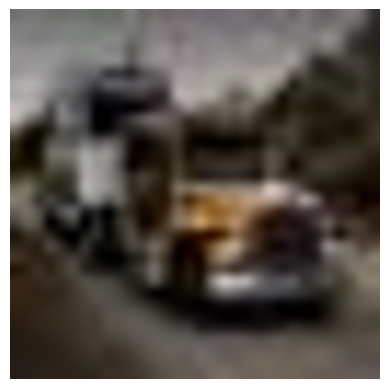

In [13]:
# De-normalize tensor before displaying with matplotlib
def denormalize(tensor, mean=(0.4693, 0.4595, 0.4128), std=(0.2353, 0.2363, 0.2653)):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

plt.imshow(denormalize(img1).permute(1, 2, 0))
plt.axis("off")
plt.show()


In [14]:
img1_sp = salt_and_pepper(0.5, 4)
op = img1_sp(img1)
op


tensor([[[-0.1445, -0.1445, -0.1279,  ..., -1.1445, -1.1612, -1.1778],
         [-0.1279, -0.1279, -0.1112,  ..., -1.1445, -1.1612, -1.1778],
         [-0.1279, -0.1279, -0.1112,  ..., -1.1445, -1.1612, -1.1945],
         ...,
         [-1.4112, -1.4112, -1.4112,  ...,  1.0000, -0.3445, -0.3445],
         [-1.4112, -1.4112, -1.4112,  ..., -0.3445, -0.3445, -0.3445],
         [-1.4112, -1.4112, -1.4112,  ..., -0.3445, -0.3445, -0.3445]],

        [[-0.1356, -0.1356, -0.1190,  ..., -1.1646, -1.1812, -1.1978],
         [-0.1190, -0.1190, -0.1024,  ..., -1.1646, -1.1812, -1.1978],
         [-0.1190, -0.1190, -0.1024,  ..., -1.1646, -1.1812, -1.2144],
         ...,
         [-1.4467, -1.4467, -1.4467,  ...,  1.0000, -0.4344, -0.4344],
         [-1.4467, -1.4467, -1.4467,  ..., -0.4344, -0.4344, -0.4344],
         [-1.4467, -1.4467, -1.4467,  ..., -0.4344, -0.4344, -0.4344]],

        [[ 0.0700,  0.0700,  0.0848,  ..., -0.8760, -0.8908, -0.9056],
         [ 0.0848,  0.0848,  0.0996,  ..., -0

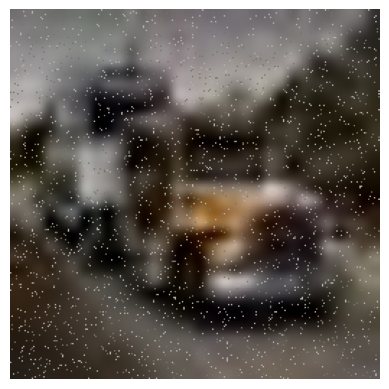

In [15]:
plt.imshow(denormalize(op).permute(1, 2, 0))
plt.axis("off")
plt.show()


In [16]:
def sp_dev(ratio, perc_noise, img):
    mn = salt_and_pepper(ratio, perc_noise)
    img_noisy = mn(img)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(denormalize(img).permute(1, 2, 0))
    plt.title("Before noise")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(denormalize(img_noisy).permute(1, 2, 0))
    plt.title("After noise")
    plt.axis("off")

    plt.show()


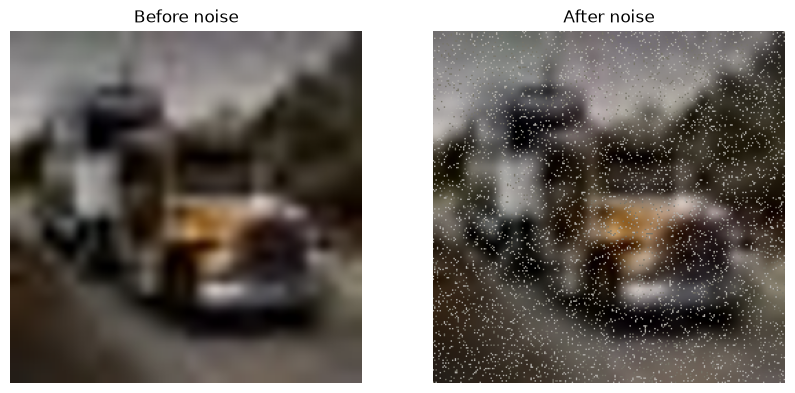

In [17]:
sp_dev(0.6, 10, img1)


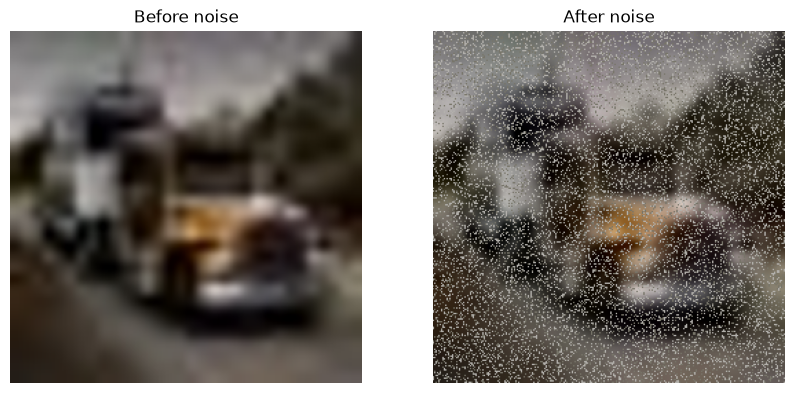

In [18]:
sp_dev(0.6, 25, img1)


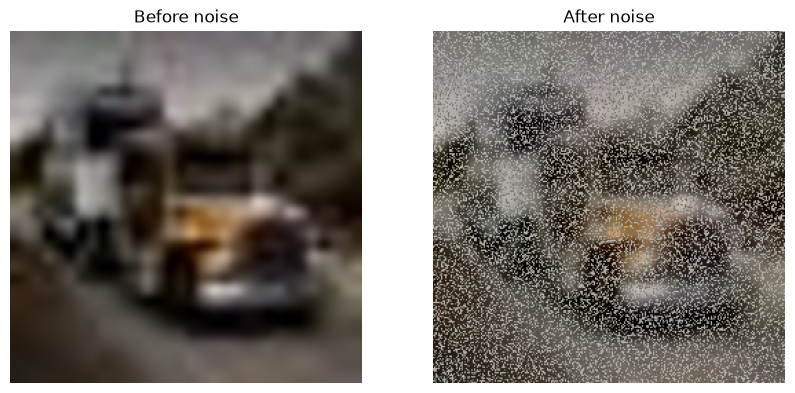

In [19]:
sp_dev(0.6, 50, img1)


<class 'torch.Tensor'>


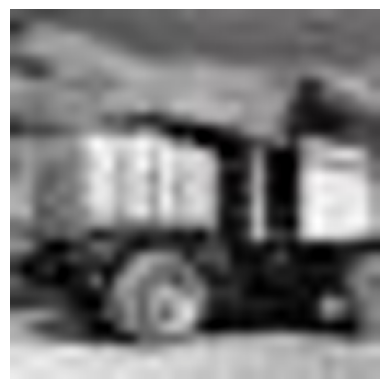

In [20]:
k = train_dataset_256[100]
print(type(k[0]))
plt.imshow(denormalize(k[0]).permute(1, 2, 0))
plt.axis("off")
plt.show()


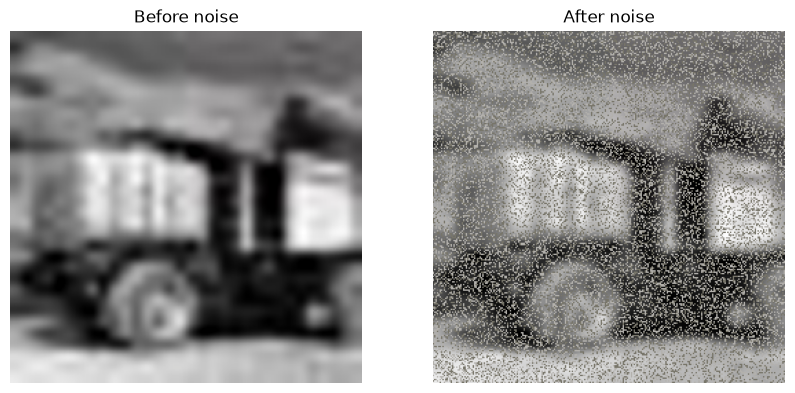

In [21]:
sp_dev(0.6, 50, k[0])


In [22]:
len(train_dataset_256)


100000

In [23]:
import copy


In [24]:
train_copy_sp_256 = copy.deepcopy(train_dataset_256)
len(train_dataset_256)


100000

In [25]:
salt_pepper_dilute = 0.30


In [26]:
num_salt_pepper_dilute = int(len(train_dataset_256) * salt_pepper_dilute )
num_salt_pepper_dilute


30000

In [27]:
cood = np.random.randint(0 , len(train_dataset_256) , num_salt_pepper_dilute)
len(cood)


30000

In [28]:
np.unique(cood)


array([    1,     4,    20, ..., 99989, 99990, 99993],
      shape=(25848,), dtype=int32)

In [29]:
cood = list(set(cood))


In [30]:
img , lab = next(iter(train_copy_sp_256))
img.shape


torch.Size([3, 256, 256])

In [31]:
len(cood)


25848

In [32]:
convert = salt_and_pepper(0.6, 10)

# Store just the set of indices that should receive noise (no tensor caching)
noisy_indices = set(cood)  # ~26k ints, negligible memory

# Override __getitem__ to apply noise on-the-fly during DataLoader iteration
import types
_orig_getitem = train_copy_sp_256.__class__.__getitem__
def _noisy_getitem(self, index):
    img_t, lbl = _orig_getitem(self, index)
    if index in noisy_indices:
        img_t = convert(img_t)
    return img_t, lbl
train_copy_sp_256.__getitem__ = types.MethodType(_noisy_getitem, train_copy_sp_256)
print(f'On-the-fly salt-and-pepper enabled for {len(noisy_indices)} / {len(train_copy_sp_256)} samples ({100*len(noisy_indices)/len(train_copy_sp_256):.1f}%)')


On-the-fly salt-and-pepper enabled for 25848 / 100000 samples (25.8%)


In [33]:
import torch
import torch.nn as nn


In [34]:
class TinyVGG(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [35]:
tvgg_1 = TinyVGG(1)


In [36]:
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dev


device(type='cuda')

In [37]:
tvgg_1.to(dev)


TinyVGG(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4)

In [38]:
from torch.utils.data import DataLoader


In [39]:
train_256 = DataLoader( train_copy_sp_256, batch_size = 32, shuffle = True )


In [40]:
import torch.optim as optim


In [41]:
optimizer = optim.Adam(tvgg_1.parameters() , lr = 0.0001 )


In [42]:
loss_fn = nn.BCELoss()


In [43]:
!pip install torchmetrics


In [44]:
from torchmetrics import Accuracy, F1Score, Precision, Recall


In [45]:
accuracy = Accuracy(task = "binary")
f1 = F1Score(task = "binary")
precision = Precision(task = "binary")
recall = Recall(task = "binary")


In [46]:
def train_data(model, dataloader, dev, optimizer, loss_fn,
               accuracy, f1, precision, recall, epoch):

    model = model.to(dev)
    model.train()

    running_loss = 0.0

    # Reset metrics
    accuracy.reset()
    f1.reset()
    precision.reset()
    recall.reset()

    # Move metrics to the same device as the model
    accuracy = accuracy.to(dev)
    f1 = f1.to(dev)
    precision = precision.to(dev)
    recall = recall.to(dev)

    for images, labels in dataloader:

        images = images.to(dev)
        labels = labels.to(dev).float()

        # Forward
        logits = model(images)
        if logits.dim() > 1 and logits.shape[1] == 1:
            logits = logits.squeeze(1)

        # Sigmoid for BCELoss
        probs = torch.sigmoid(logits)

        # Loss
        loss_value = loss_fn(probs, labels)

        # Backward
        optimizer.zero_grad()
        loss_value.backward()
        optimizer.step()

        running_loss += loss_value.item()

        # Metrics
        accuracy.update(probs, labels.int())
        f1.update(probs, labels.int())
        precision.update(probs, labels.int())
        recall.update(probs, labels.int())

    epoch_loss = running_loss / len(dataloader)

    epoch_accuracy = accuracy.compute().item()
    epoch_f1 = f1.compute().item()
    epoch_precision = precision.compute().item()
    epoch_recall = recall.compute().item()

    print(
        f"Epoch {epoch} | "
        f"Train Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.4f} | "
        f"F1: {epoch_f1:.4f} | "
        f"Precision: {epoch_precision:.4f} | "
        f"Recall: {epoch_recall:.4f}"
    )

    return (
        epoch_loss,
        epoch_accuracy,
        epoch_f1,
        epoch_precision,
        epoch_recall
    )


In [47]:
def test_data(model, dataloader, dev, loss_fn,
              accuracy, f1, precision, recall):

    model = model.to(dev)
    model.eval()

    running_loss = 0.0

    accuracy.reset()
    f1.reset()
    precision.reset()
    recall.reset()

    # Move metrics to the same device as the model
    accuracy = accuracy.to(dev)
    f1 = f1.to(dev)
    precision = precision.to(dev)
    recall = recall.to(dev)

    with torch.inference_mode():

        for images, labels in dataloader:

            images = images.to(dev)
            labels = labels.to(dev).float()

            # Forward
            logits = model(images)
            if logits.dim() > 1 and logits.shape[1] == 1:
                logits = logits.squeeze(1)

            # Convert logits to probabilities
            probs = torch.sigmoid(logits)

            # Loss
            loss_value = loss_fn(probs, labels)

            running_loss += loss_value.item()

            # Metrics
            accuracy.update(probs, labels.int())
            f1.update(probs, labels.int())
            precision.update(probs, labels.int())
            recall.update(probs, labels.int())

    test_loss = running_loss / len(dataloader)

    test_accuracy = accuracy.compute().item()
    test_f1 = f1.compute().item()
    test_precision = precision.compute().item()
    test_recall = recall.compute().item()

    print(
        f"Test | "
        f"Loss: {test_loss:.4f} | "
        f"Accuracy: {test_accuracy:.4f} | "
        f"F1: {test_f1:.4f} | "
        f"Precision: {test_precision:.4f} | "
        f"Recall: {test_recall:.4f}"
    )

    return (
        test_loss,
        test_accuracy,
        test_f1,
        test_precision,
        test_recall
    )


## for size 256


In [48]:
train_data(tvgg_1, train_256, dev, optimizer, loss_fn, accuracy, f1, precision, recall, 1)


Epoch 1 | Train Loss: 0.4871 | Accuracy: 0.7581 | F1: 0.7569 | Precision: 0.7607 | Recall: 0.7531


(0.4870717640733719,
 0.7580900192260742,
 0.7568670511245728,
 0.760712742805481,
 0.753059983253479)

In [49]:
test_data(tvgg_1, train_256, dev, loss_fn, accuracy, f1, precision, recall)


Test | Loss: 0.3508 | Accuracy: 0.8533 | F1: 0.8504 | Precision: 0.8672 | Recall: 0.8342


(0.35083827786445615,
 0.8532500267028809,
 0.8504031896591187,
 0.8672266602516174,
 0.8342199921607971)

## for size 32


In [50]:
class TinyVGG32(nn.Module):

    def __init__(self, num_classes=1):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [51]:
train_32_ds = DataLoader( train_dataset_32, batch_size = 32, shuffle = True )
tvgg_2 = TinyVGG32(1).to(dev)
optimizer_32 = optim.Adam(tvgg_2.parameters(), lr=0.0001)


In [52]:
train_data(
    tvgg_2,
    train_32_ds,
    dev,
    optimizer_32,
    loss_fn,
    accuracy,
    f1,
    precision,
    recall,
    1
)


Epoch 1 | Train Loss: 0.5253 | Accuracy: 0.7301 | F1: 0.7271 | Precision: 0.7352 | Recall: 0.7192


(0.5252790947294235,
 0.7301099896430969,
 0.7271385192871094,
 0.7352333664894104,
 0.719219982624054)

In [53]:
test_data(
    tvgg_2,
    train_32_ds,
    dev,
    loss_fn,
    accuracy,
    f1,
    precision,
    recall
)


Test | Loss: 0.4186 | Accuracy: 0.8058 | F1: 0.7874 | Precision: 0.8700 | Recall: 0.7191


(0.41858701766490936,
 0.8058199882507324,
 0.7873770594596863,
 0.870009183883667,
 0.7190799713134766)

## so we will use dataloader  train_256


## trying efficient net b0


In [54]:
from torchvision.models import efficientnet_b0


In [55]:
eff = efficientnet_b0(weights = "DEFAULT")
eff.classifier[1] = nn.Linear(in_features=eff.classifier[1].in_features, out_features=1)
eff = eff.to(dev)
optimizer_eff = optim.Adam(eff.parameters(), lr=0.0001)


In [56]:
train_data(eff, train_256, dev, optimizer_eff, loss_fn, accuracy, f1, precision, recall, 1)


Epoch 1 | Train Loss: 0.1221 | Accuracy: 0.9543 | F1: 0.9543 | Precision: 0.9551 | Recall: 0.9534


(0.12208776832178235,
 0.9543300271034241,
 0.9542893171310425,
 0.9551401734352112,
 0.9534400105476379)

In [57]:
test_data(eff, train_256, dev, loss_fn, accuracy, f1, precision, recall)


Test | Loss: 0.0387 | Accuracy: 0.9874 | F1: 0.9874 | Precision: 0.9863 | Recall: 0.9885


(0.038668980353660884,
 0.9874200224876404,
 0.9874340891838074,
 0.9863306283950806,
 0.98853999376297)

## using reduce lr on plateau scheduler


In [58]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau( optimizer_eff, mode = "max", factor = 0.5, patience = 2, threshold = 0.001, min_lr = 1e-6)


In [59]:
epochs = 2
for epoch in range(1, epochs + 1):

    train_loss, train_acc, train_f1, train_prec, train_rec = train_data(
        eff, train_256, dev, optimizer_eff, loss_fn,
        accuracy, f1, precision, recall, epoch
    )

    val_loss, val_accuracy, val_f1, val_precision, val_recall = test_data(
        eff, train_256, dev, loss_fn,
        accuracy, f1, precision, recall
    )

    
    scheduler.step(val_f1)


Epoch 1 | Train Loss: 0.0583 | Accuracy: 0.9780 | F1: 0.9780 | Precision: 0.9789 | Recall: 0.9771
Test | Loss: 0.0249 | Accuracy: 0.9911 | F1: 0.9910 | Precision: 0.9958 | Recall: 0.9863
Epoch 2 | Train Loss: 0.0384 | Accuracy: 0.9863 | F1: 0.9863 | Precision: 0.9869 | Recall: 0.9856
Test | Loss: 0.0349 | Accuracy: 0.9877 | F1: 0.9878 | Precision: 0.9775 | Recall: 0.9983
